# Lab 4, Day 2 — Fashion-MNIST Classification

Build a classifier with proper validation tracking and early stopping, then read a
confusion matrix as an error-analysis tool rather than decoration. See
`Lab4_Day2_Instructions.md` for the full walkthrough.

This notebook is just a shell: the data loading, model, training loop, and analysis
are yours to write.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:" , device)


Using device: cpu


## Step 1: Load Fashion-MNIST and prepare loaders (`stage_b_classification.py`)

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, random_split

transform = transforms.ToTensor()
train_full = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

# TODO: load Fashion-MNIST (already cached from Day 1), split off a validation set,
# build DataLoaders - shuffle=True for training only

from stage_b_classification import load_fashion_mnist

train_loader, val_loader, test_loader = load_fashion_mnist(train_full , test_set)

print("Train:" , len(train_loader))
print("Validation:" , len(val_loader))
print("Test:" , len(test_loader))
print(f"Classes: {train_full.classes}")


Train: 844
Validation: 94
Test: 157
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Look at the data before you model it

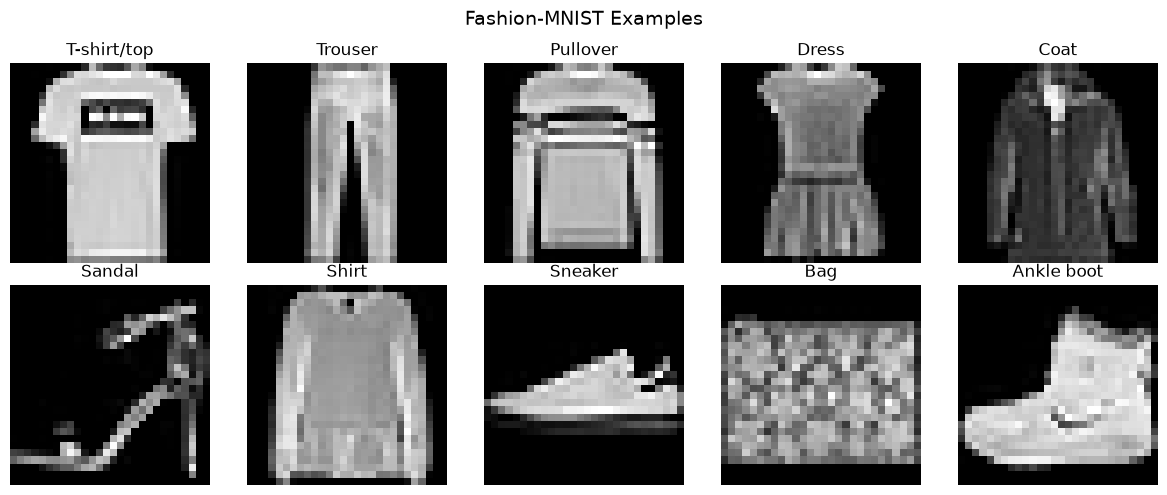

In [8]:
# TODO: plot a handful of example images, one (or a few) per class - use
# train_set.classes for the human-readable label names. This is worth doing before
# you build anything: you will be asked later whether the confusion matrix's mistakes
# are reasonable, and you cannot judge that without having actually looked at the images.

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    # Find an image belonging to class i
    for image, label in train_full:
        if label == i:
            ax.imshow(image.squeeze(), cmap="gray")
            ax.set_title(train_full.classes[label])
            ax.axis("off")
            break

plt.suptitle("Fashion-MNIST Examples", fontsize=14)
plt.tight_layout()
plt.show()


## Step 2: The classifier

In [9]:
# TODO: Flatten -> Linear -> ReLU -> Linear (10 classes), raw scores, NO softmax -
# CrossEntropyLoss applies it internally
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()


## Step 3: Train with validation tracking and early stopping

In [10]:
# TODO: train_with_early_stopping (or write it yourself) - track train loss and val
# accuracy per epoch, patience-based stopping (not a single bad epoch), .clone() the
# best state_dict before restoring it
from train import train_with_early_stopping
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_accuracies = train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20,
    patience=3
)

torch.save(model.state_dict(), "stage_b.pt")

Device being used for training: cpu
Model device: cpu
Epoch [1/20], Train Loss: 0.5576, Validation Accuracy: 0.8262
Epoch [2/20], Train Loss: 0.4064, Validation Accuracy: 0.8535
Epoch [3/20], Train Loss: 0.3657, Validation Accuracy: 0.8682
Epoch [4/20], Train Loss: 0.3383, Validation Accuracy: 0.8728
Epoch [5/20], Train Loss: 0.3201, Validation Accuracy: 0.8688
Epoch [6/20], Train Loss: 0.3015, Validation Accuracy: 0.8845
Epoch [7/20], Train Loss: 0.2880, Validation Accuracy: 0.8848
Epoch [8/20], Train Loss: 0.2766, Validation Accuracy: 0.8805
Epoch [9/20], Train Loss: 0.2664, Validation Accuracy: 0.8827
Epoch [10/20], Train Loss: 0.2565, Validation Accuracy: 0.8928
Epoch [11/20], Train Loss: 0.2488, Validation Accuracy: 0.8825
Epoch [12/20], Train Loss: 0.2410, Validation Accuracy: 0.8918
Epoch [13/20], Train Loss: 0.2328, Validation Accuracy: 0.8885
Early stopping triggered.


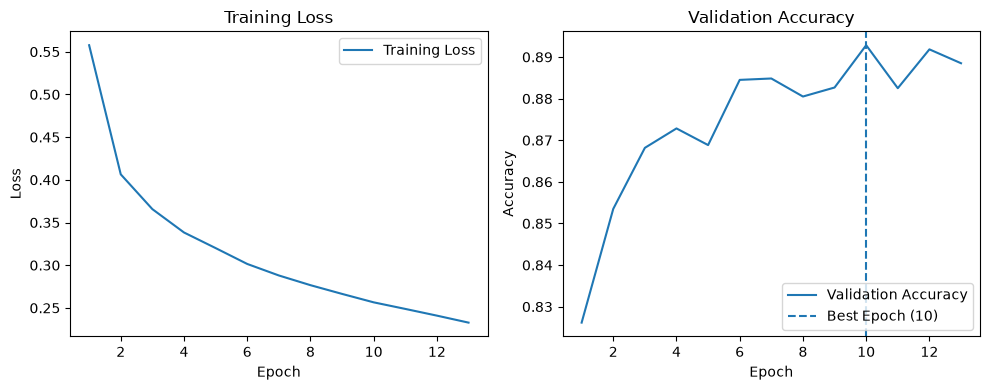

Best Epoch: 10
Best Validation Accuracy: 89.28%
Test Accuracy: 0.8841
Test Accuracy: 88.41%


In [11]:
# TODO: plot training loss and validation accuracy curves, report test accuracy
import matplotlib.pyplot as plt

# Find the epoch with the best validation accuracy
best_epoch = val_accuracies.index(max(val_accuracies)) + 1
best_val_accuracy = max(val_accuracies)

epochs_ran = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 4))

# Training loss
plt.subplot(1, 2, 1)
plt.plot(epochs_ran, train_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

# Validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_ran, val_accuracies, label="Validation Accuracy")
plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Accuracy: {best_val_accuracy:.2%}")


# Test accuracy
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        predictions = outputs.argmax(dim=1)

        total += y.size(0)
        correct += (predictions == y).sum().item()

test_accuracy = correct / total

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

## Step 4: Confusion matrix

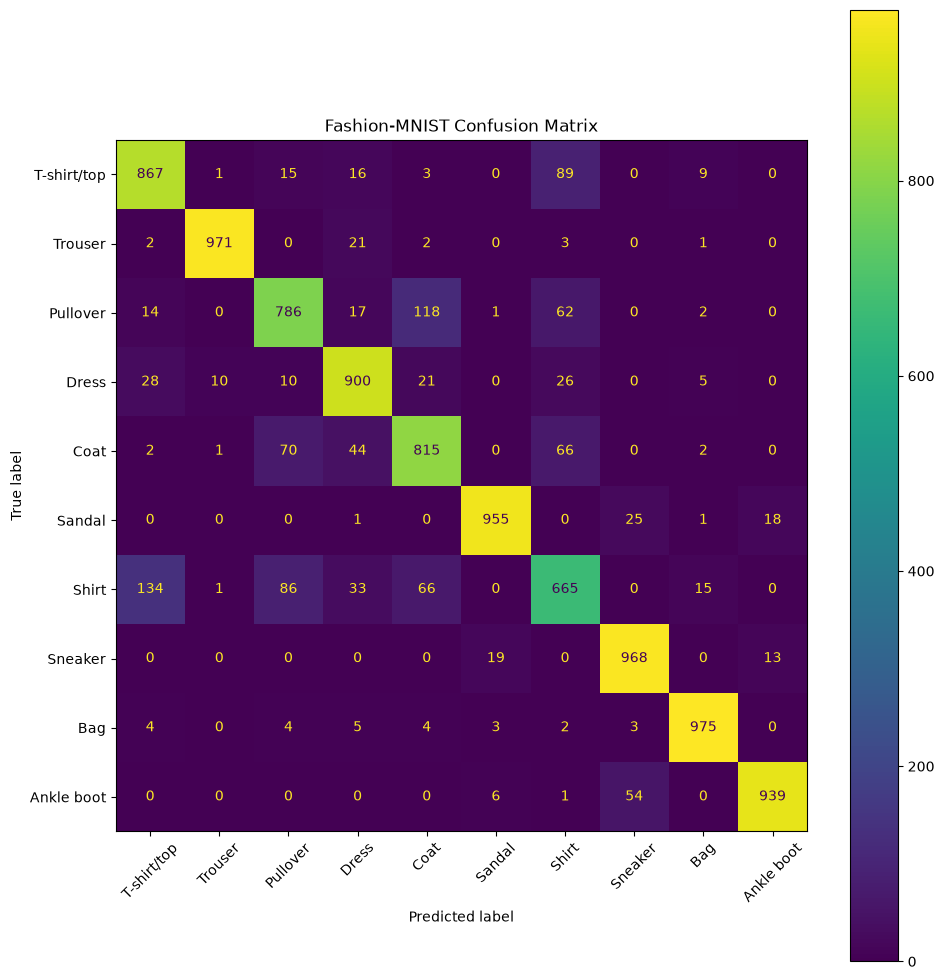

In [12]:
# TODO: confusion matrix on the test set - which classes get confused, and does that
# make sense given what those classes actually look like?

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(y.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_full.classes
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Fashion-MNIST Confusion Matrix")
plt.tight_layout()
plt.show()


### Written prompt

> **Look at your training curves: validation accuracy flattens while training loss keeps
> falling. Describe what the model is doing in that gap, and explain what your early
> stopping rule actually protected you from.**

The model is still improving on the training data because the training loss keeps decreasing, but its performance on unseen validation data has mostly stopped improving. This suggests the model is beginning to overfit the training data. Early stopping protected us from continuing to train after validation performance had stopped improving and from ending up with a worse model.



### Closing reflection

> **Across both days you used a framework to do things you had previously done by hand.
> Name one thing PyTorch genuinely did for you, and one thing it did *not* do (something
> you still had to get right yourself).**

PyTorch handled the automatic calculation of gradients and parameter updates through backpropagation and optimizers. However, I still had to correctly prepare the data, choose the model and loss function, handle tensor shapes, and evaluate the model properly.